In [ ]:
import sys
#sys.path.insert(0, '/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/software/scPrinter/printer3/lib/python3.11/site-packages')

import time
import pandas as pd
import numpy as np
import os
import scprinter as scp
import cupy
#sys.path.append('/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/software/sminiforge3/envs/printer3113/lib/python3.1/site-packages')
import cupy as cp
import cupyx as cpx
import time
import rmm

import scanpy as sc
import anndata

import snapatac2 as snap

In [17]:
#frags = pd.read_csv("merged.sort.clean.frags.bed", sep='\t', header=None)
#frags

In [18]:
frag_num_list = [100000000]

In [60]:
for frag_num in frag_num_list:
    frags_filt = frags.sample(frag_num)
    frags_filt.to_csv(f"/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/frags.filt.rmbc.{frag_num}.tsv.gz", sep='\t', header=False, index=False)

In [19]:
printer = scp.pp.import_fragments(
            path_to_frags= "frags.filt.rmbc.100000000.tsv.gz",
            barcodes=None,
            savename='frags.filt.rmbc.100000000.h5ad',
            genome=scp.genome.hg38,
            min_num_fragments=0, min_tsse=0,
            sorted_by_barcode=False,
            low_memory=False,
            )

single input
Detecting the shift in the paired end fragments file
If you think the above message is wrong, please check the input file format
You are now using the beta auto_detect_shift function, this overwrites the plus_shift and minus_shift you provided
If you believe the auto_detect_shift is wrong, please set auto_detect_shift=False
detected plus_shift and minus_shift are 20 11 for frags.filt.rmbc.100000000.tsv.gz


In [11]:
printer.close()

In [ ]:
scp.pp.sync_footprints(printer,
                   printer.insertion_file.obs_names,
                   f"frags.filt.rmbc.100000000")

In [ ]:
printer

In [43]:
for fold in range(5):
    model_config= scp.tl.seq_model_config(printer,
                                     region_path=f'/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/all.peaks.stdchrom.clean.bed',
                                     cell_grouping=printer.obs_names,
                                     group_names='Glio_Bulk',
                                     genome=printer.genome,
                                     fold=fold,
                                     overwrite_bigwig=False,
                                     model_name='Glio_Bulk',
                                     additional_config={
                                        "notes": "v3",
                                        "tags": ["Glio",
                                            "Bulk",
                                            f"fold{fold}"]},
                                     path_swap=(work_dir, ''),
                                     config_save_path=f'/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/configs/Glio_fold{fold}.JSON')
    model_configs.append(model_config)

bigwig for Glio_Bulk already exists, skip
bigwig for Glio_Bulk already exists, skip
bigwig for Glio_Bulk already exists, skip
bigwig for Glio_Bulk already exists, skip
bigwig for Glio_Bulk already exists, skip


In [42]:
for fold in range(5):
    scp.tl.launch_seq2print(model_config_path=f'/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/configs/Glio_fold{fold}.JSON',
                            temp_dir='/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/temp',
                            model_dir='/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/model',
                            data_dir='/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial',
                            gpus=fold,
                            wandb_project='Glioblastoma', # wandb helps you manage loggins
                            verbose=True,
                            launch=False # launch=True, this command would launch the scripts directly,
                            # otherwise, it will just display the commands, you should copy them and run them.
                           )

Please copy the following command in your terminal and run it to start the job
CUDA_VISIBLE_DEVICES=0 seq2print_train --config /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/configs/Glio_fold0.JSON --temp_dir /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/temp --model_dir /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/model --data_dir /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial --project Glioblastoma --enable_wandb
Please copy the following command in your terminal and run it to start the job
CUDA_VISIBLE_DEVICES=1 seq2print_train --config /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/configs/Glio_fold1.JSON --temp_dir /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/temp --model_dir /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutoria

### generate sequence attribution score

In [19]:
work_dir = '/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/'

In [20]:
pretrain_models = ['Glio_Bulk_fold0-stellar-fire-11.pt',
                  'Glio_Bulk_fold1-worldly-blaze-6.pt',
                  'Glio_100m_fold2-deft-feather-8.pt',
                  'Glio_Bulk_fold3-charmed-serenity-9.pt',
                  'Glio_Bulk_fold4-pleasant-disco-10.pt']
model_path = [os.path.join(work_dir, "model", m) for m in pretrain_models]

In [21]:
model_path

['/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/model/Glio_Bulk_fold0-stellar-fire-11.pt',
 '/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/model/Glio_Bulk_fold1-worldly-blaze-6.pt',
 '/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/model/Glio_100m_fold2-deft-feather-8.pt',
 '/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/model/Glio_Bulk_fold3-charmed-serenity-9.pt',
 '/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/model/Glio_Bulk_fold4-pleasant-disco-10.pt']

In [53]:
# This will generate the sequence attribution scores for the footprint, you can input multiple models, it will iterate over them
scp.tl.seq_attr_seq2print(
    genome=printer.genome,
    region_path='/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/all.peaks.stdchrom.clean.bed',
    model_type='seq2print',
    model_path=model_path,
    gpus=[0],
    preset='footprint',
    overwrite=False,
    verbose=True,
    launch=False)

Using preset, the following parameters would be overwritten
using wrapper: just_sum
using nth_output: 0-30
using decay: 0.85
Please copy the following command in your terminal and run it to start the job
seq2print_attr --pt /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/model/Glio_Bulk_fold0-stellar-fire-11.pt --peaks /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/all.peaks.stdchrom.clean.bed --method shap_hypo --wrapper just_sum --nth_output 0-30 --gpus 0 --genome hg38 --decay 0.85 --save_key deepshap --model_norm footprint
Using preset, the following parameters would be overwritten
using wrapper: just_sum
using nth_output: 0-30
using decay: 0.85
Please copy the following command in your terminal and run it to start the job
seq2print_attr --pt /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/model/Glio_Bulk_fold1-worldly-blaze-6.pt --peaks /mimer/NOBACKUP/groups/naiss2024-22-1126/

In [54]:
# This will generate the sequence attribution scores for the count head, you can input multiple models, it will iterate over them
scp.tl.seq_attr_seq2print(
    genome=printer.genome,
    region_path='/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/all.peaks.stdchrom.clean.bed',
    model_type='seq2print',
    model_path=model_path,
    gpus=[0],
    preset='count',
    overwrite=False,
    verbose=True,
    launch=False)

Using preset, the following parameters would be overwritten
using wrapper: count
using nth_output: 0
using decay: 0.85
Please copy the following command in your terminal and run it to start the job
seq2print_attr --pt /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/model/Glio_Bulk_fold0-stellar-fire-11.pt --peaks /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/all.peaks.stdchrom.clean.bed --method shap_hypo --wrapper count --nth_output 0 --gpus 0 --genome hg38 --decay 0.85 --save_key deepshap --model_norm count
Using preset, the following parameters would be overwritten
using wrapper: count
using nth_output: 0
using decay: 0.85
Please copy the following command in your terminal and run it to start the job
seq2print_attr --pt /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/model/Glio_Bulk_fold1-worldly-blaze-6.pt --peaks /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2pr

### Call denovo motifs from the sequence attribution scores


In [22]:
peak = '/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/all.peaks.stdchrom.clean.bed'

In [61]:
if not os.path.exists(f'{work_dir}/modisco'):
    os.makedirs(f'{work_dir}/modisco')
scp.tl.seq_denovo_seq2print(model_path=model_path,
                            region_path=peak,
                            genome=printer.genome,
                            gpus=[0],
                            preset='footprint',
                            save_path=f'{work_dir}/modisco/modisco.footprint.h5',
                            verbose=True)

In [64]:
if not os.path.exists(f'{work_dir}/modisco'):
    os.makedirs(f'{work_dir}/modisco')
scp.tl.seq_denovo_seq2print(model_path=model_path,
                            region_path=peak,
                            genome=printer.genome,
                            gpus=[0],
                            preset='count',
                            save_path=f'{work_dir}/modisco/modisco.count.h5',
                            verbose=True)

Please copy the following command in your terminal and run it to start the job
seq2print_modisco motifs -s /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/all.peaks.stdchrom.clean.bed_ohe.npz -a /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial//modisco/modisco.count.h5.avg.hypo.npz -n 1000000 -o /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial//modisco/modisco.count.h5 -w 1000 -r 1 --solver modularity


In [67]:
printer.close()

### Generate the delta effects for those denovo motifs

In [23]:
peak

'/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/all.peaks.stdchrom.clean.bed'

In [24]:
work_dir

'/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/'

In [25]:
scp.tl.delta_effects_seq2print

<function scprinter.tools.delta_effects_seq2print(model_path: 'str | Path | list[str | Path]', genome: 'Genome' = None, region_path: 'str' = None, motifs: 'Motifs | str' = None, motif_sample_mode: "Literal['argmax', 'multinomial']" = 'argmax', lora_ids: 'list | None' = None, prefix: 'str' = '', sample_num=25000, gpus: 'int | list[int] | None' = None, collapse_footprint_across_bins=False, random_seq=False, overwrite=False, verbose=False, launch=False, flank=200, vmin=-0.3, vmax=0.3, save_path=None, plot=True)>

In [17]:
de = scp.tl.delta_effects_seq2print(model_path,
                               genome=scp.genome.hg38,
                               region_path=peak,
                               motifs= f'{work_dir}/modisco/modisco.footprint.h5',
                               prefix='footprint',
                               gpus=[0], # use the second gpu
                               sample_num=20000,
                               save_path=f'{work_dir}/modisco/delta_effects_footprint',
                               plot=True, vmin='auto', vmax='auto')

Using vmin/vmax: -0.07 0.07


In [79]:
de = scp.tl.delta_effects_seq2print(model_path,
                               genome=scp.genome.hg38,
                               region_path=peak,
                               motifs= f'{work_dir}/modisco/Modisco.count.h5',
                               prefix='count',
                               gpus=[0], # use the second gpu
                               sample_num=20000,
                               save_path=f'{work_dir}/modisco/delta_effects_count',
                               plot=True, vmin='auto', vmax='auto')

seq2print_delta --pt /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/model/Glio_Bulk_fold0-stellar-fire-11.pt /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/model/Glio_Bulk_fold1-worldly-blaze-6.pt /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/model/Glio_100m_fold2-deft-feather-8.pt /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/model/Glio_Bulk_fold3-charmed-serenity-9.pt /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/model/Glio_Bulk_fold4-pleasant-disco-10.pt --genome hg38 --peaks /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/all.peaks.stdchrom.clean.bed --motifs /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial//modisco/delta_effects_count/motif.npy --mode argmax --gpus 0 --sample_num 20000 --output /mimer/

### Create a report for these denovo motifs (match to known cisBP ones + delta effects)

In [17]:
scp.datasets.FigR_motifs_human_meme

'/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/software/temp/scprinter/CisBP_Human_FigR_meme'

In [ ]:
scp.tl.modisco_report(modisco_h5=f'{work_dir}/modisco/modisco.footprint.h5',
                     save_path=f'{work_dir}/modisco_footprint',
                     meme_motif=scp.datasets.FigR_motifs_human_meme,
                     is_writing_tomtom_matrix=False,
                     top_n_matches=3,
                     delta_effect_path=f'{work_dir}/modisco/delta_effects_footprint')

In [85]:
scp.tl.modisco_report(modisco_h5=f'{work_dir}/modisco/modisco.count.h5',
                     save_path=f'{work_dir}/modisco_count',
                     meme_motif=scp.datasets.FigR_motifs_mouse_meme,
                     is_writing_tomtom_matrix=False,
                     top_n_matches=3,
                     delta_effect_path=f'{work_dir}/modisco/delta_effects_count')

Creating logos for reference motifs:   0%|          | 0/890 [00:00<?, ?it/s]

Processing /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial//modisco/Modisco.count.h5


2025-02-06 23:29:12 - ERROR - Failed to load image at 'file:///mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial//modisco/delta_effects_count/pos_patterns.pattern_0.png': URLError: <urlopen error [Errno 2] No such file or directory: '/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial//modisco/delta_effects_count/pos_patterns.pattern_0.png'>
2025-02-06 23:29:12 - ERROR - Failed to load image at 'file:///mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial//modisco/delta_effects_count/pos_patterns.pattern_1.png': URLError: <urlopen error [Errno 2] No such file or directory: '/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial//modisco/delta_effects_count/pos_patterns.pattern_1.png'>
2025-02-06 23:29:12 - ERROR - Failed to load image at 'file:///mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial//

,pattern,num_seqlets,modisco_cwm_fwd,modisco_cwm_rev,delta_effects,match0,qval0,match0_logo,match1,qval1,match1_logo,match2,qval2,match2_logo
0,pos_patterns.pattern_0,29909,/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial//modisco/Modisco.count.h5_figs/trimmed_logos/pos_patterns.pattern_0.cwm.fwd.png,/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial//modisco/Modisco.count.h5_figs/trimmed_logos/pos_patterns.pattern_0.cwm.rev.png,/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial//modisco/delta_effects_count/pos_patterns.pattern_0.png,Fosl2,2.255444e-05,/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/ref_motif_logos/Fosl2.png,Fos,6.103731e-05,/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/ref_motif_logos/Fos.png,Nfe2l3,0.000261,/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/ref_motif_logos/Nfe2l3.png
1,pos_patterns.pattern_1,19953,/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial//modisco/Modisco.count.h5_figs/trimmed_logos/pos_patterns.pattern_1.cwm.fwd.png,/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial//modisco/Modisco.count.h5_figs/trimmed_logos/pos_patterns.pattern_1.cwm.rev.png,/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial//modisco/delta_effects_count/pos_patterns.pattern_1.png,Nfix,1.415714e-06,/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/ref_motif_logos/Nfix.png,Nfia,4.470987e-05,/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/ref_motif_logos/Nfia.png,Nfic,0.000149,/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/ref_motif_logos/Nfic.png
2,pos_patterns.pattern_2,17112,/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial//modisco/Modisco.count.h5_figs/trimmed_logos/pos_patterns.pattern_2.cwm.fwd.png,/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial//modisco/Modisco.count.h5_figs/trimmed_logos/pos_patterns.pattern_2.cwm.rev.png,/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial//modisco/delta_effects_count/pos_patterns.pattern_2.png,Sox3,1.409351e-05,/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/ref_motif_logos/Sox3.png,Sox2,2.348926e-05,/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/ref_motif_logos/Sox2.png,Sox4,0.000253,/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/ref_motif_logos/Sox4.png
3,pos_patterns.pattern_3,15416,/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial//modisco/Modisco.count.h5_figs/trimmed_logos/pos_patterns.pattern_3.cwm.fwd.png,/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial//modisco/Modisco.count.h5_figs/trimmed_logos/pos_patterns.pattern_3.cwm.rev.png,/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial//modisco/delta_effects_count/pos_patterns.pattern_3.png,Ctcf,-7.562708e-09,/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/ref_motif_logos/Ctcf.png,Ctcfl,8.545984e-07,/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/ref_motif_logos/Ctcfl.png,Zfp383,0.035334,/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/ref_motif_logos/Zfp383.png
4,pos_patterns.pattern_4,13186,/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial//modisco/Modisco.count.h5_figs/trimmed_logos/pos_patt

### We can do chromvar on both the cisBP motifs, and the de-novo motifs

In [55]:
printer.close()

In [26]:
printer = scp.load_printer('frags.filt.rmbc.100000000.h5ad', scp.genome.hg38)

In [27]:
printer

head project
AnnData object with n_obs x n_vars = 38 x 0 backed at 'frags.filt.rmbc.100000000.h5ad'
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'frag_path', 'frag_sample_name', 'tsse'
    uns: 'frac_overlap_TSS', 'bias_path', 'gff_db', 'TSS_profile', 'binding score', 'insertion', 'footprints', 'bias_bw', 'genome', 'library_tsse', 'unique_string', 'reference_sequences'
    obsm: 'insertion_chr21', 'insertion_chr7', 'insertion_chr11', 'insertion_chr4', 'insertion_chr12', 'insertion_chr6', 'insertion_chr8', 'insertion_chrX', 'insertion_chr18', 'insertion_chr13', 'insertion_chr14', 'insertion_chr19', 'insertion_chr22', 'insertion_chr5', 'insertion_chr3', 'insertion_chr15', 'insertion_chr9', 'insertion_chrY', 'insertion_chr16', 'insertion_chr10', 'fragment_paired', 'insertion_chr20', 'insertion_chr1', 'insertion_chr17', 'insertion_chr2'


In [ ]:
adata = scp.pp.make_peak_matrix(printer,
                       regions=peak,
                       region_width=300,
                       cell_grouping=None,
                       group_names=None,
                       sparse=True)

Loading insertion profiles


In [90]:
adata.write(f'{work_dir}/cell_peak.h5ad')

In [18]:
adata = snap.read(f'{work_dir}/cell_peak.h5ad')

In [29]:
adata.close()

In [21]:
import warnings
warnings.filterwarnings("ignore")

In [23]:
from rmm.allocators.cupy import rmm_cupy_allocator

In [24]:
rmm.reinitialize(
    managed_memory=True, # Allows oversubscription
    pool_allocator=True, # default is False
    devices=0, # GPU device IDs to register. By default registers only GPU 0.
)

cp.cuda.set_allocator(rmm_cupy_allocator)

In [74]:
adata = anndata.read_h5ad(f'{work_dir}/cell_peak.h5ad')
coverage = adata.X.sum(axis=0)
adata = adata[:, coverage > 0]

In [75]:
adata
scp.chromvar.sample_bg_peaks(adata,
                             genome=scp.genome.hg38,
                             method='chromvar',
                             niterations=250)

Fetching GC content:   0%|          | 0/121125 [00:00<?, ?it/s]

/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/software/scPrinter/printer3/lib/python3.11/site-packages/scprinter/utils.py:242: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["gc_content"] = gc_contents


Sampling nearest neighbors
NNDescent (2500, 2)


Sampling background peaks:   0%|          | 0/2500 [00:00<?, ?it/s]

/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/software/scPrinter/printer3/lib/python3.11/site-packages/scprinter/chromvar.py:162: RuntimeWarning: divide by zero encountered in divide
  p = (p_tmp / bin_density)[bin_membership]
/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/software/scPrinter/printer3/lib/python3.11/site-packages/scprinter/chromvar.py:162: RuntimeWarning: invalid value encountered in divide
  p = (p_tmp / bin_density)[bin_membership]


array([[ 51790, 119632,  73480, ...,  75608,  58287,  16823],
       [  9569,  94393,  16361, ..., 104896,  16131,  85339],
       [107666,  38191,  79199, ..., 109332,  37056,  70473],
       ...,
       [  2094,  17978, 103055, ...,  51356,  42766,  81060],
       [ 35134,  13537,  28035, ...,  79576,  27450,  24439],
       [ 63148,  63497,  59890, ...,  59767,  59334, 108108]])

In [76]:
motif = scp.motifs.FigR_Human_Motifs(scp.genome.hg38,
                                     bg=list(adata.uns['bg_freq']),
                                     n_jobs=100,
                                     pvalue=5e-5, mode='motifmatchr')

In [77]:
motif.prep_scanner(
    None,
    pvalue=5e-5,
)
motif.chromvar_scan(adata)

  0%|          | 0/242250 [00:00<?, ?it/s]

In [78]:
chromvar = scp.chromvar.compute_deviations(adata, chunk_size=50000, device='cuda')

Computing expectation reads per cell and peak...


Processing chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Processing background peaks:   0%|          | 0/250 [00:00<?, ?it/s]

/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/software/scPrinter/printer3/lib/python3.11/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


In [80]:
work_dir

'/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/'

In [81]:
chromvar.write_h5ad(f'{work_dir}/chromvar_cisbp.h5ad')

In [83]:
chromvar = anndata.read_h5ad(f'{work_dir}/chromvar_cisbp.h5ad')

In [84]:
sc.pp.scale(chromvar)  # Standardize the data (mean=0, var=1)
sc.tl.pca(chromvar, n_comps=20)  # Reduce to 50 components
sc.pp.neighbors(chromvar, n_pcs=20, n_neighbors=15)  # Adjust as needed
sc.tl.umap(chromvar)

In [130]:
barcodegroups = pd.read_csv('new.group.txt',sep='\t')

In [131]:
barcodegroups.index = barcodegroups['sample']

In [87]:
chromvar.obs = barcodegroups

In [88]:
Xumap = pd.DataFrame(chromvar.obsm['X_umap'])

In [89]:
Xumap['group'] = barcodegroups['group']

... storing 'group' as categorical


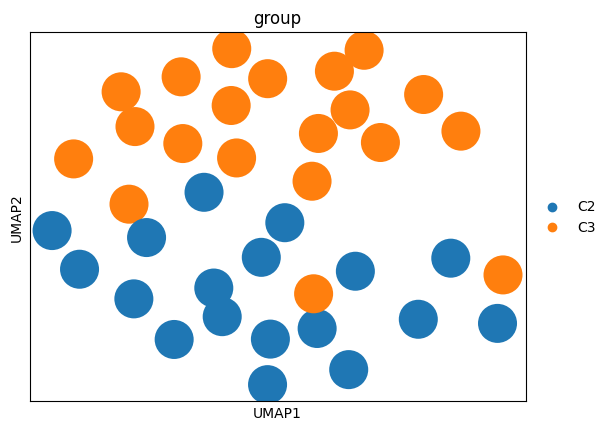

In [91]:
sc.pl.umap(chromvar,color = 'group',) 

In [115]:
hits_footprint = scp.tl.seq_denovo_callhits(modisco_output=f'{work_dir}/modisco/modisco.footprint.h5',
                           model_path=model_path,
                           region_path=peak,
                           device='cuda:0',
                           preset='footprint',
                           save_path=f'{work_dir}/modisco/finemo_footprint',
                           overwrite=False,
                           verbose=True,
                           launch=True, # Usually should be True when return_hits=True, but I run it once already
                           return_hits=True)

/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial//modisco


In [117]:
hits_footprint

,chr,start,end,start_untrimmed,end_untrimmed,motif_name,hit_coefficient,hit_coefficient_global,hit_correlation,hit_importance,strand,peak_name,peak_id,distance_to_center
0,chr1,816984,816989,816972,817002,pos_patterns.pattern_16,1.965476,152.862670,0.946384,61.226562,-,NaN,0,316
1,chr1,816985,816990,816973,817003,pos_patterns.pattern_16,0.631721,49.131386,0.933067,57.357426,-,NaN,0,315
2,chr1,816996,817001,816984,817014,pos_patterns.pattern_16,1.411375,109.768050,0.864344,55.042970,-,NaN,0,304
3,chr1,817010,817015,816997,817027,pos_patterns.pattern_16,1.169644,90.967700,0.849198,53.441402,+,NaN,0,290
4,chr1,817050,817056,817038,817068,neg_patterns.pattern_0,0.277027,21.545477,0.848068,36.916990,-,NaN,0,249
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3158284,chrX,5491560,5491565,5491548,5491578,pos_patterns.pattern_16,2.836487,804.167100,0.939585,170.015640,-,NaN,121124,192
3158285,chrX,5491561,5491566,5491549,5491579,pos_patterns.pattern_16,2.371488,672.335940,0.950052,157.726560,-,NaN,121124,193
3158286,chrX,5491568,5491573,5491556,5491586,pos_patterns.pattern_16,1.463794,414.997340,0.953913,82.699210,-,NaN,121124,200
3158287,chrX,5491623,5491628,5491611,5491641,pos_patterns.pattern_16,1.192254,338.013800,0.900196,85.671875,-,NaN,121124,255


In [3]:
import pickle

In [4]:
with open('hits_footprint.pkl','rb') as f:
    hits_footprint = pickle.load(f)

In [5]:
hits_footprint

,chr,start,end,start_untrimmed,end_untrimmed,motif_name,hit_coefficient,hit_coefficient_global,hit_correlation,hit_importance,strand,peak_name,peak_id,distance_to_center
0,chr1,816984,816989,816972,817002,pos_patterns.pattern_16,1.965476,152.862670,0.946384,61.226562,-,NaN,0,316
1,chr1,816985,816990,816973,817003,pos_patterns.pattern_16,0.631721,49.131386,0.933067,57.357426,-,NaN,0,315
2,chr1,816996,817001,816984,817014,pos_patterns.pattern_16,1.411375,109.768050,0.864344,55.042970,-,NaN,0,304
3,chr1,817010,817015,816997,817027,pos_patterns.pattern_16,1.169644,90.967700,0.849198,53.441402,+,NaN,0,290
4,chr1,817050,817056,817038,817068,neg_patterns.pattern_0,0.277027,21.545477,0.848068,36.916990,-,NaN,0,249
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3158284,chrX,5491560,5491565,5491548,5491578,pos_patterns.pattern_16,2.836487,804.167100,0.939585,170.015640,-,NaN,121124,192
3158285,chrX,5491561,5491566,5491549,5491579,pos_patterns.pattern_16,2.371488,672.335940,0.950052,157.726560,-,NaN,121124,193
3158286,chrX,5491568,5491573,5491556,5491586,pos_patterns.pattern_16,1.463794,414.997340,0.953913,82.699210,-,NaN,121124,200
3158287,chrX,5491623,5491628,5491611,5491641,pos_patterns.pattern_16,1.192254,338.013800,0.900196,85.671875,-,NaN,121124,255


In [138]:
with open('hits_count.pkl','wb') as f:
    pickle.dump(hits_count,f)

In [116]:
hits_count = scp.tl.seq_denovo_callhits(modisco_output=f'{work_dir}/modisco/modisco.count.h5',
                           model_path=model_path,
                           region_path=peak,
                           device='cuda:0',
                           preset='count',
                           save_path=f'{work_dir}/modisco/finemo_count',
                           overwrite=False,
                           verbose=True,
                           launch=True,
                           return_hits=True)

/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial//modisco


## Let’s take the footprint de-novo motifs as an example

In [92]:
adata = anndata.read_h5ad(f'/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/cell_peak2.h5ad')
# This takes the hits_tsv, and create the motif matching data matrix and motif_name list that chromvar needs

In [93]:
adata

AnnData object with n_obs × n_vars = 38 × 121125

In [95]:
hits_footprint

,chr,start,end,start_untrimmed,end_untrimmed,motif_name,hit_coefficient,hit_coefficient_global,hit_correlation,hit_importance,strand,peak_name,peak_id,distance_to_center
0,chr1,816984,816989,816972,817002,pos_patterns.pattern_16,1.965476,152.862670,0.946384,61.226562,-,NaN,0,316
1,chr1,816985,816990,816973,817003,pos_patterns.pattern_16,0.631721,49.131386,0.933067,57.357426,-,NaN,0,315
2,chr1,816996,817001,816984,817014,pos_patterns.pattern_16,1.411375,109.768050,0.864344,55.042970,-,NaN,0,304
3,chr1,817010,817015,816997,817027,pos_patterns.pattern_16,1.169644,90.967700,0.849198,53.441402,+,NaN,0,290
4,chr1,817050,817056,817038,817068,neg_patterns.pattern_0,0.277027,21.545477,0.848068,36.916990,-,NaN,0,249
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3158284,chrX,5491560,5491565,5491548,5491578,pos_patterns.pattern_16,2.836487,804.167100,0.939585,170.015640,-,NaN,121124,192
3158285,chrX,5491561,5491566,5491549,5491579,pos_patterns.pattern_16,2.371488,672.335940,0.950052,157.726560,-,NaN,121124,193
3158286,chrX,5491568,5491573,5491556,5491586,pos_patterns.pattern_16,1.463794,414.997340,0.953913,82.699210,-,NaN,121124,200
3158287,chrX,5491623,5491628,5491611,5491641,pos_patterns.pattern_16,1.192254,338.013800,0.900196,85.671875,-,NaN,121124,255


In [96]:
motif_uniq = np.sort(hits_footprint['motif_name'].unique())
motif2id = {m:i for i,m in enumerate(motif_uniq)}
ids = [motif2id[m] for m in hits_footprint['motif_name']]
match_mm = np.zeros((adata.shape[1], len(motif_uniq)))
match_mm[hits_footprint['peak_id'], ids] += 1
match_mm

array([[1., 1., 0., ..., 0., 0., 1.],
       [1., 1., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 1., 0., ..., 0., 0., 0.],
       [1., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 1., 0., 0.]])

In [97]:
adata.varm['motif_match'] = match_mm
motif_uniq = [f'footprint_{xx}' for xx in motif_uniq]
adata.uns['motif_name'] = motif_uniq
# Filter after putting in motif match, because, we use all peaks above to call hits
coverage = adata.X.sum(axis=0)
adata = adata[:, coverage > 0]
adata

View of AnnData object with n_obs × n_vars = 38 × 121125
    uns: 'motif_name'
    varm: 'motif_match'

In [98]:
scp.chromvar.sample_bg_peaks(adata,
                             genome=scp.genome.hg38,
                             method='chromvar',
                             niterations=250)

Fetching GC content:   0%|          | 0/121125 [00:00<?, ?it/s]

/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/software/scPrinter/printer3/lib/python3.11/site-packages/scprinter/utils.py:242: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["gc_content"] = gc_contents


Sampling nearest neighbors
NNDescent (2500, 2)


Sampling background peaks:   0%|          | 0/2500 [00:00<?, ?it/s]

/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/software/scPrinter/printer3/lib/python3.11/site-packages/scprinter/chromvar.py:162: RuntimeWarning: divide by zero encountered in divide
  p = (p_tmp / bin_density)[bin_membership]
/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/software/scPrinter/printer3/lib/python3.11/site-packages/scprinter/chromvar.py:162: RuntimeWarning: invalid value encountered in divide
  p = (p_tmp / bin_density)[bin_membership]


array([[ 93275,  76169,  74201, ...,  54577,  10580,  68104],
       [ 89769, 113300,  41882, ..., 110424,   8298,  67738],
       [ 12029, 107631,  63776, ...,  36170,  15901,  54707],
       ...,
       [ 18379,  42766,  99727, ...,  64083,  76732,  64612],
       [ 74576, 108156, 120197, ...,  51606,  18028, 121123],
       [105751,  64773,  97875, ...,  86424,  27778, 101280]])

In [99]:
chromvar_denovo = scp.chromvar.compute_deviations(adata, chunk_size=50000, device='cuda')

Computing expectation reads per cell and peak...


Processing chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Processing background peaks:   0%|          | 0/250 [00:00<?, ?it/s]

/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/software/scPrinter/printer3/lib/python3.11/site-packages/anndata/_core/anndata.py:402: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


In [100]:
sc.pp.scale(chromvar_denovo)  # Standardize the data (mean=0, var=1)
sc.tl.pca(chromvar_denovo, n_comps=20)  # Reduce to 50 components
sc.pp.neighbors(chromvar_denovo, n_pcs=20, n_neighbors=15)  # Adjust as needed
sc.tl.umap(chromvar_denovo)

In [101]:
chromvar_denovo.obs = barcodegroups

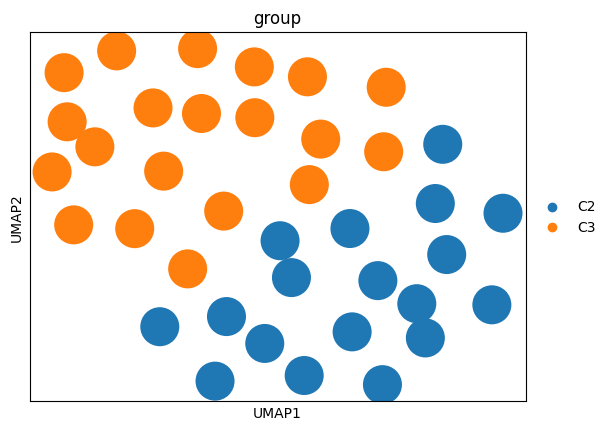

In [102]:
sc.pl.umap(chromvar_denovo,color = 'group') 

In [103]:
chromvar_denovo.write_h5ad(f'{work_dir}/chromvar_denovo.h5ad')

### Train the LoRA models

In [127]:
barcodegroups2 = pd.read_csv('group.info2.txt',sep= '\t')

In [129]:
cell_grouping, group_names = scp.utils.df2cell_grouping(printer, barcodegroups2)

In [106]:
model_path

['/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/model/Glio_Bulk_fold0-stellar-fire-11.pt',
 '/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/model/Glio_Bulk_fold1-worldly-blaze-6.pt',
 '/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/model/Glio_100m_fold2-deft-feather-8.pt',
 '/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/model/Glio_Bulk_fold3-charmed-serenity-9.pt',
 '/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/model/Glio_Bulk_fold4-pleasant-disco-10.pt']

In [136]:
lora_configs = []
for fold, model in enumerate(model_path):
    print(fold,model)
    lora_config = scp.tl.seq_lora_model_config(printer,
                                            region_path=f'all.peaks.stdchrom.clean.bed',
                                            cell_grouping=cell_grouping,
                                            group_names=group_names,
                                            embeddings = chromvar_denovo.obsm['X_umap'],
                                            genome=scp.genome.hg38,
                                            pretrain_model=model,
                                            overwrite_barcode=True,
                                            model_name=f'Glio_LoRA',
                                            fold=fold,
                                            model_config=f'/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/configs/Glio_fold{fold}.JSON',
                                         #   additional_group_attr=barcodegroups[['group']],
                                            additional_lora_config={
                                            "lr":3e-4, # put smaller lr for further fintune
                                            "notes": "v3",
                                            "tags": ["Glio",
                                                     "Bulk",
                                                     "LoRA",
                                                f"fold{fold}"]},
                                            path_swap=(work_dir, ''),
                                            config_save_path=f'/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/configs/Glio_lora_fold{fold}.JSON')
   # break
    lora_configs.append(lora_config)

0 /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/model/Glio_Bulk_fold0-stellar-fire-11.pt
1 /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/model/Glio_Bulk_fold1-worldly-blaze-6.pt
2 /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/model/Glio_100m_fold2-deft-feather-8.pt
3 /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/model/Glio_Bulk_fold3-charmed-serenity-9.pt
4 /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/model/Glio_Bulk_fold4-pleasant-disco-10.pt


In [33]:
import pickle

In [137]:
# Save (dump) the object to a file
with open('lora_config.allsamples.pkl', 'wb') as file:
    pickle.dump(lora_configs, file)

In [35]:
# Save (dump) the object to a file
with open('lora_config.allsamples.pkl', 'rb') as file:
   lora_config =  pickle.load(file)

#### launch the lora training process. When set launch=True, the process would be launched directly, otherwise it would just print the command. You’ll need to copy the command and run it in the terminal yourself.|



In [35]:
for fold in range(5):
    scp.tl.launch_seq2print(model_config_path=f'{work_dir}/configs/Glio_lora_fold{fold}.JSON',
                            temp_dir='/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/temp',
                            model_dir='/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/model',
                            data_dir='/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial',
                            gpus=[0],
                            wandb_project='scPrinter_seq_tutorial', verbose=True, launch=False)

Please copy the following command in your terminal and run it to start the job
CUDA_VISIBLE_DEVICES=[0] seq2print_train --config /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial//configs/Glio_lora_fold0.JSON --temp_dir /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/temp --model_dir /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/model --data_dir /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial --project scPrinter_seq_tutorial --enable_wandb
Please copy the following command in your terminal and run it to start the job
CUDA_VISIBLE_DEVICES=[0] seq2print_train --config /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial//configs/Glio_lora_fold1.JSON --temp_dir /mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/PRINT_rev/Glio_tutorial/temp --model_dir /mimer/NOBACKUP

### For the LoRA on 1000 pseudobulks, let’s pick some interesting regions to visualize




In [138]:
lora_models = ['Glio_LoRA_fold0-scarlet-resonance-67.pt',
               'Glio_LoRA_fold1-good-leaf-68.pt' ,
               'Glio_LoRA_fold2-worthy-jazz-64.pt' ,
               'Glio_LoRA_fold3-sage-elevator-63.pt' ,
               'Glio_LoRA_fold4-vague-waterfall-66.pt'
              ]

In [139]:
group_names

array(['U3008', 'U3013', 'U3020', 'U3024', 'U3027', 'U3031', 'U3033',
       'U3034', 'U3035', 'U3037', 'U3039', 'U3046', 'U3053', 'U3060',
       'U3062', 'U3068', 'U3071', 'U3073', 'U3078', 'U3082', 'U3084',
       'U3088', 'U3093', 'U3110', 'U3112', 'U3117', 'U3118', 'U3121',
       'U3137', 'U3140', 'U3155', 'U3167', 'U3173', 'U3198', 'U3202',
       'U3230', 'U3308', 'U3429'], dtype=object)

In [ ]:
vs = scp.tl.seq_tfbs_seq2print(seq_attr_count=None,
                          seq_attr_footprint=None,
                          genome=printer.genome,
                          region_path=f'/mimer/NOBACKUP/groups/naiss2024-22-1126/pengwei/Glio/02.seq2print/all.peaks.stdchrom.clean.bed',
                          gpus=[0],
                          model_type='lora',
                          model_path=[os.path.join(work_dir, 'model', m) for m in lora_models],
                          lora_config=lora_config,
                          group_names=group_names,
                          verbose=False,
                          launch=True,
                          return_adata=True, # turn this as True
                          overwrite_seqattr=False,
                          save_key='Glio_bulklora_example_region1', # and input a save_key
                          save_path=work_dir)

In [42]:
with open('seq_tfbs_seq2print.vsC3.pkl', 'rb') as file3:
   vs_C3 = pickle.load(file3)
with open('seq_tfbs_seq2print.vsC2.pkl', 'rb') as file2:
   vs_C2 = pickle.load(file2)

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [ ]:
scp.tl.get_footprint_score(printer,
                       save_key='test_region',
                       cell_grouping=cell_grouping,
                       group_names=group_names,
                       regions = ["chr2:215410680-215411480"], backed=True, overwrite=True)

In [45]:
vs_C2.obsm['chr2:215410680-215411480']

array([[0.01323398, 0.01408463, 0.0142217 , ..., 0.01899149, 0.01840207,
        0.01921043],
       [0.01369509, 0.01325768, 0.01388434, ..., 0.02224407, 0.02008415,
        0.02053526]], dtype=float32)